Caso não tenha as bibliotecas instaladas, favor criar um virtualenv e instalar o requirements.txt:

``` [Shell]
python -m venv .venv
pip install -r requirements.txt
```

## 1. Análise Exploratória dos Dados (EDA)

Carregamento do dataset, visualização das primeiras linhas e realização de análise gráfica para entender melhor os dados.

### Informações sobre a base de dados

- **Nome da base:** Imdb Most popular Films and series
- **Fonte:** [Kaggle](https://www.kaggle.com/datasets/mazenramadan/imdb-most-popular-films-and-series/data)
- **Objetivo:** Prever automaticamente se um filme será "Bem avaliado" (nota >= 7) ou "Mal avaliado" (nota < 7).

A base foi filtrada para considerar apenas filmes, removendo séries e registros duplicados, para evitar erros no treinamento dos modelos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# estilo dos graficos
sns.set_theme(style="whitegrid")

# carregamento do dataset
caminho_dataset = 'dataset/imdb.csv'
df_original = pd.read_csv(caminho_dataset)
df = df_original.copy()

# exemplo das primeirsa linhas do dataset
df.head()

,Name,Date,Rate,Votes,Genre,Duration,Type,Certificate,Episodes,Nudity,Violence,Profanity,Alcohol,Frightening
0,No Time to Die,2021,7.6,"107,163","Action, Adventure, Thriller",163.0,Film,PG-13,-,Mild,Moderate,Mild,Mild,Moderate
1,The Guilty,2021,6.3,"64,375","Crime, Drama, Thriller",90.0,Film,R,-,NaN,NaN,Severe,NaN,Moderate
2,The Many Saints of Newark,2021,6.4,"27,145","Crime, Drama",120.0,Film,R,-,Moderate,Severe,Severe,Moderate,Moderate
3,Venom: Let There Be Carnage,2021,6.4,"30,443","Action, Adventure, Sci-Fi",97.0,Film,PG-13,-,NaN,Moderate,Moderate,Mild,Moderate
4,Dune,2021,8.3,"84,636","Action, Adventure, Drama",155.0,Film,PG-13,-,NaN,Moderate,NaN,Mild,Moderate


In [2]:
import numpy as np

tipos_obras = df_original['Type'].unique()
print("Tipos de obras no dataset:", tipos_obras)

# mudando todas as series para NaN para ignorar no dataset
mascara_series = df_original['Type'].str.contains('Series', case=False, na=False)
df_original.loc[mascara_series, 'Duration'] = np.nan

# verificando quantidade de series com o print
print(f"Quantidade de filmes/séries sem duração agora: {df_original['Duration'].isna().sum()}")

Tipos de obras no dataset: <StringArray>
['Film', 'Series']
Length: 2, dtype: str
Quantidade de filmes/séries sem duração agora: 1852


In [3]:
# Remover registros duplicados com mesmo Name, Date e Rate
antes = len(df_original)
df_original = df_original.drop_duplicates(subset=['Name', 'Date', 'Rate'], keep='first')
depois = len(df_original)
print(f"Registros duplicados removidos: {antes - depois}")

Registros duplicados removidos: 1150


### Gráfico 1: Distribuição das Notas dos Filmes

Gráfico exibindo distribuição das notas dos filmes.

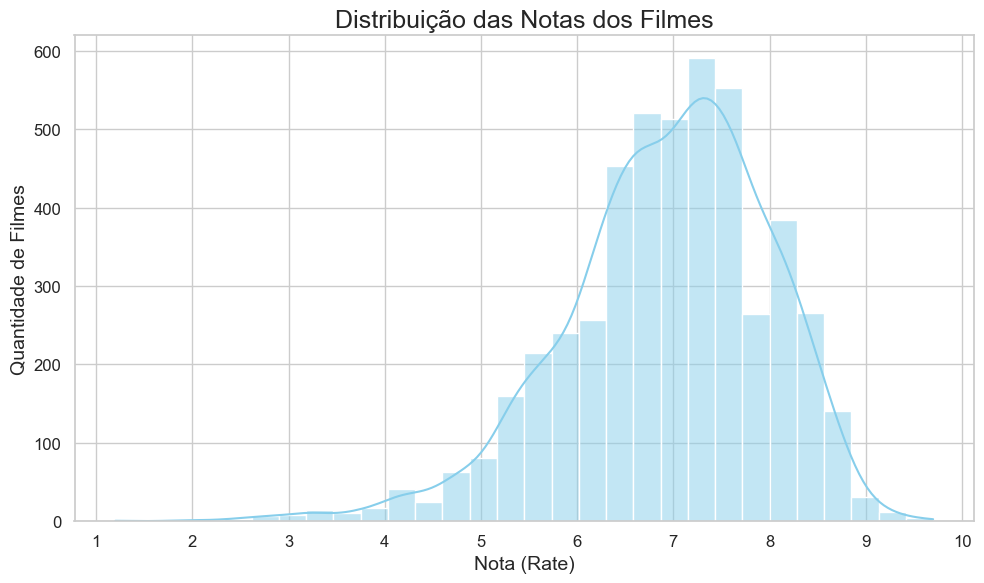

In [4]:
# grafico geral de distribuicao de notas
rate_num = pd.to_numeric(df_original['Rate'], errors='coerce')
plt.figure(figsize=(10, 6))
sns.histplot(rate_num, bins=30, kde=True, color='skyblue')
plt.title('Distribuição das Notas dos Filmes', fontsize=18)
plt.xlabel('Nota (Rate)', fontsize=14)
plt.ylabel('Quantidade de Filmes', fontsize=14)
plt.xticks(range(1, 11), fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico 2: Relação entre número de votos e nota

Este gráfico procura se há alguma relação entre o número de votos e a nota do filme.

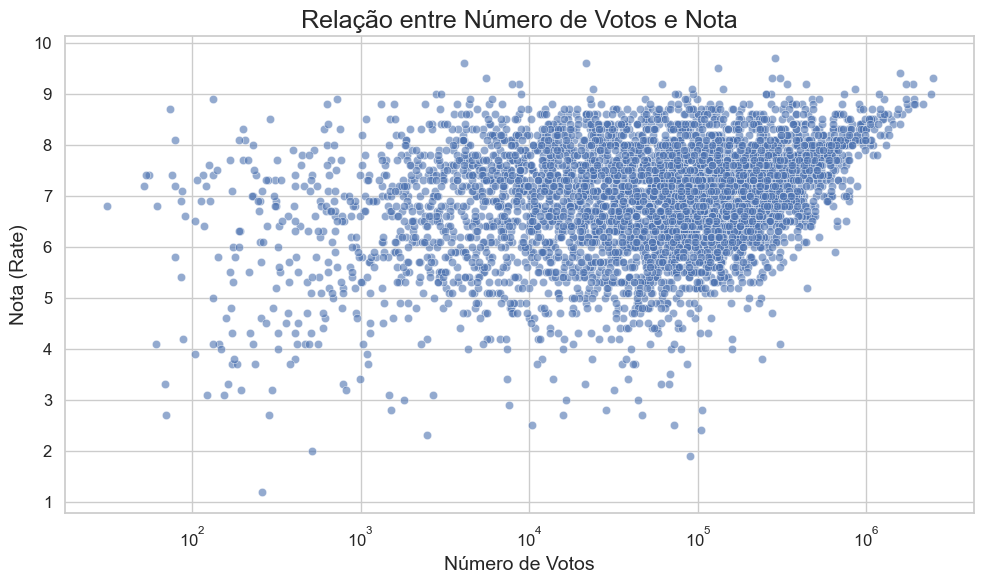

In [5]:
# passando votes para valor numerico
votes_temp = pd.to_numeric(df_original['Votes'].astype(str).str.replace(',', ''), errors='coerce')
rate_temp = pd.to_numeric(df_original['Rate'], errors='coerce')

# removendo linhas com valores nao numericos
mask_validos = votes_temp.notna() & rate_temp.notna()
votes_temp = votes_temp[mask_validos]
rate_temp = rate_temp[mask_validos]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=votes_temp, y=rate_temp, alpha=0.6)
plt.title('Relação entre Número de Votos e Nota', fontsize=18)
plt.xlabel('Número de Votos', fontsize=14)
plt.ylabel('Nota (Rate)', fontsize=14)
plt.xscale('log') # escala em log
plt.xticks(fontsize=12)
plt.yticks(range(1, 11), fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico 3: Duração dos Filmes por Faixa de Nota

Análise de como a duração dos filmes varia de acordo com a faixa de nota.

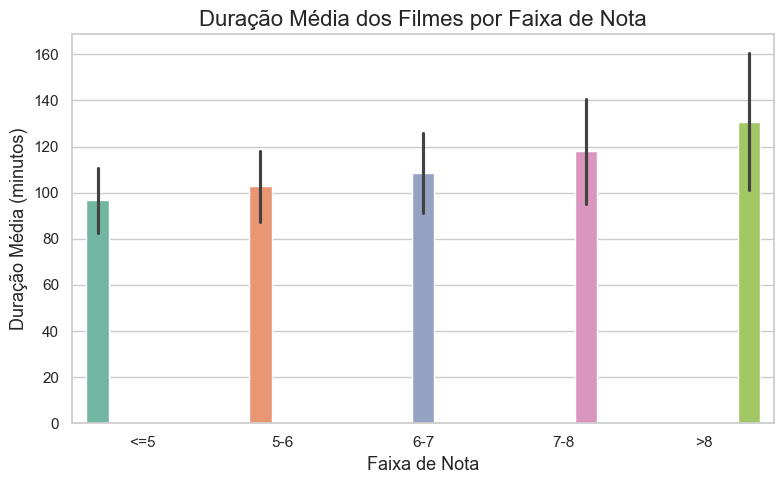

In [6]:
bins = [0, 5, 6, 7, 8, 10]
labels = ['<=5', '5-6', '6-7', '7-8', '>8']
df_original['Faixa_Nota'] = pd.cut(pd.to_numeric(df_original['Rate'], errors='coerce'), bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Faixa_Nota',
    y='Duration',
    data=df_original,
    errorbar='sd',
    palette='Set2',
    hue='Faixa_Nota',
    legend=False
)
plt.title('Duração Média dos Filmes por Faixa de Nota', fontsize=16)
plt.xlabel('Faixa de Nota', fontsize=13)
plt.ylabel('Duração Média (minutos)', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

## 2. Pré-processamento dos Dados

Preparação dos dados para o treinamento dos modelos de Machine Learning (conversão de tipos, definição do target e features e divisão dos dados).

In [7]:
# Conversão da coluna Rate e Votes para valor numérico
# Criação da coluna alvo target
# Seleção das features e remoção de valore não numericos
# Divisão em treino e teste

from sklearn.model_selection import train_test_split

# Rate para float
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

# Votes para float
votes_numeric = pd.to_numeric(df['Votes'].str.replace(',', ''), errors='coerce')
df['Votes'] = votes_numeric

# target: 1 se Rate >= 7, senão 0
df['target'] = (df['Rate'] >= 7).astype(int)

# seleção de  features
# As features selecionadas são Date, Votes e Duration
X = df[['Date', 'Votes', 'Duration']].copy()
X['Date'] = pd.to_numeric(X['Date'], errors='coerce')
y = df['target']

# Remove as linhas com valores nulos
mask_valid = X.notna().all(axis=1)
X = X[mask_valid]
y = y[mask_valid]

# Divisão de treino e teste 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# preview das primeiras linhas do pre-processamento.
X_train.head()

,Date,Votes,Duration
2857,2021,18244.0,96.0
2956,2004,185552.0,127.0
1906,2020,86317.0,123.0
5091,2016,170350.0,107.0
1621,2019,48427.0,90.0


## 3. Treinamento dos Modelos de Machine Learning

Nesta etapa é feito o treinamento usando 4 algoritmos diferentes: Árvore de Decisão, Regressão Logística, KNN e Naive Bayes.

In [8]:
# Importação dos modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

modelos = {
    'Árvore de Decisão': DecisionTreeClassifier(random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Treinando os modelos
treinados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    treinados[nome] = modelo

print("Modelos treinados.")

Modelos treinados.


## 4. Avaliação dos Modelos

A avaliação de desempenho dos modelos será feita com a matriz de confusão (visual e numérica) e o classification report para cada modelo.


Modelo: Árvore de Decisão


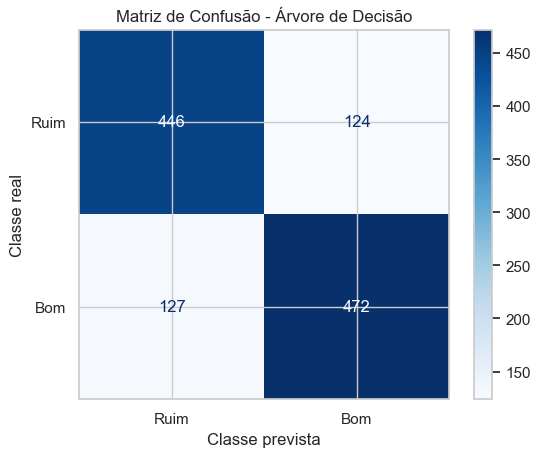

Classification Report:
              precision    recall  f1-score   support

        Ruim      0.778     0.782     0.780       570
         Bom      0.792     0.788     0.790       599

    accuracy                          0.785      1169
   macro avg      0.785     0.785     0.785      1169
weighted avg      0.785     0.785     0.785      1169


Modelo: Regressão Logística


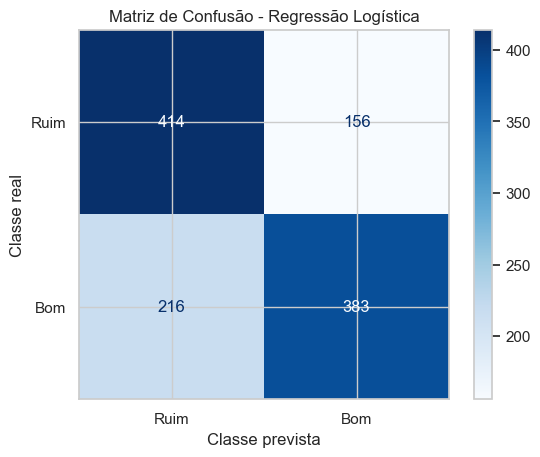

Classification Report:
              precision    recall  f1-score   support

        Ruim      0.657     0.726     0.690       570
         Bom      0.711     0.639     0.673       599

    accuracy                          0.682      1169
   macro avg      0.684     0.683     0.682      1169
weighted avg      0.685     0.682     0.681      1169


Modelo: KNN


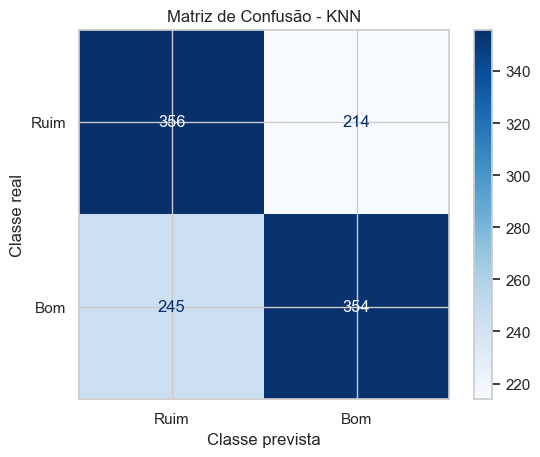

Classification Report:
              precision    recall  f1-score   support

        Ruim      0.592     0.625     0.608       570
         Bom      0.623     0.591     0.607       599

    accuracy                          0.607      1169
   macro avg      0.608     0.608     0.607      1169
weighted avg      0.608     0.607     0.607      1169


Modelo: Naive Bayes


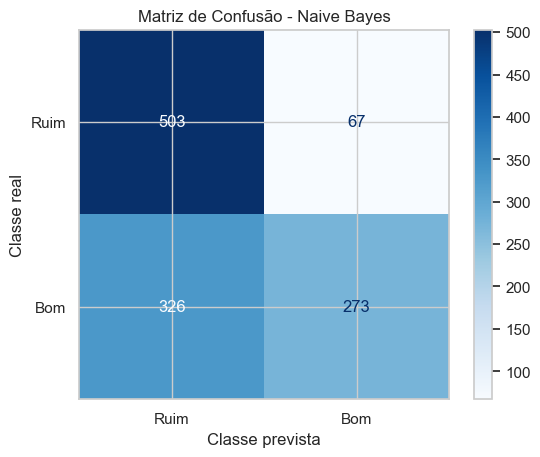

Classification Report:
              precision    recall  f1-score   support

        Ruim      0.607     0.882     0.719       570
         Bom      0.803     0.456     0.581       599

    accuracy                          0.664      1169
   macro avg      0.705     0.669     0.650      1169
weighted avg      0.707     0.664     0.649      1169



In [9]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Define os rótulos das classes
rotulos = ['Ruim', 'Bom']

for nome, modelo in treinados.items():
    print(f"\nModelo: {nome}")
    y_pred = modelo.predict(X_test)
    # Matriz de Confusão
    matriz = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=rotulos)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.xlabel('Classe prevista')
    plt.ylabel('Classe real')
    plt.show()
    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3, target_names=rotulos))

## 5. Função de Predição para Novos Filmes

Uma função que recebe os dados de um filme (Ano, Votos, Duração) e utiliza o melhor modelo treinado para prever se o filme será "Bem Avaliado" (1) ou não (0).

In [10]:
# Função de predição usando o melhor modelo (exemplo: Regressão Logística)
melhor_modelo = treinados['Árvore de Decisão']

def previsao_filme(ano, votos, duracao):
    """
    Recebe ano (int), votos (int ou float), duração (float) e retorna 1 (bem avaliado) ou 0 (não).
    """
    entrada = pd.DataFrame({
        'Date': [ano],
        'Votes': [votos],
        'Duration': [duracao]
    })
    print(f'Filme teste: \n{entrada}.')
    return int(melhor_modelo.predict(entrada)[0])

# Exemplo de uso da função:
exemplo = previsao_filme(2022, 15000, 120.0)
print(f"Exemplo de previsão para filme: {exemplo} (1 = Bem Avaliado, 0 = Não)")


Filme teste: 
   Date  Votes  Duration
0  2022  15000     120.0.
Exemplo de previsão para filme: 0 (1 = Bem Avaliado, 0 = Não)


*Neste exemplo, o filme foi avaliado com "0", ou seja, ruim.*